# Notebook 02 - Exploratory Data Analysis
## Project: Graph-Aware Explainable AI for AML Detection
### Module: UMADXD-60-M, UWE Bristol

**Purpose:** Explore the IBM AMLworld HI-Small dataset before modelling.  
**Key questions:**
- What does the class imbalance look like visually?
- How are transaction amounts distributed across illicit vs legitimate?
- What is the temporal coverage of the dataset?

**Kernel:** graphaml (Python 3.11)  
**Author:** Charan Rajashekar  


In [1]:
# Imports and reproducibility seed
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import random
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Display settings
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

print("Libraries loaded")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Libraries loaded
Pandas version: 2.2.3
Numpy version: 1.26.4


In [ ]:
# Load raw data
df = pd.read_csv("../data/raw/HI-Small_Trans.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Total transactions: {len(df):,}")
print(f"Illicit transactions: {df['Is Laundering'].sum():,}")
print(f"Illicit rate: {df['Is Laundering'].mean()*100:.3f}%")

Shape: (5078345, 11)
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
Total transactions: 5,078,345
Illicit transactions: 5,177
Illicit rate: 0.102%


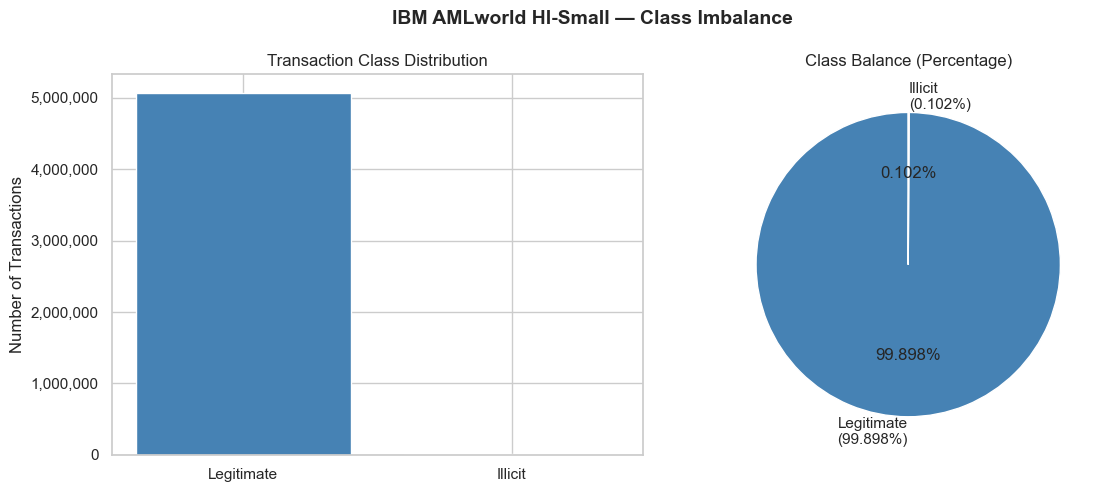

Figure saved to outputs/


In [3]:
#Class imbalance visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
class_counts = df['Is Laundering'].value_counts()
axes[0].bar(['Legitimate', 'Illicit'], 
            class_counts.values,
            color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Class Distribution')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Percentage plot
axes[1].pie([class_counts[0], class_counts[1]],
            labels=['Legitimate\n(99.898%)', 'Illicit\n(0.102%)'],
            colors=['steelblue', 'crimson'],
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Class Balance (Percentage)')

plt.suptitle('IBM AMLworld HI-Small — Class Imbalance', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/fig01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/")